# Hands-On Project: Stellar Luminosity

## 1. Establishing environment

In [24]:
# Required libraries
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import sys
import numpy as np 
import matplotlib.pyplot as plt

# Libraries' versions
print("Python version:", sys.version)
print("NumPy version:", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)

Python version: 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]
NumPy version: 2.5.1
Matplotlib version: 3.11.1



As we are using NumPy library, then we are going to load the dataset as NumPy arrays:

In [26]:
mass = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
luminosity = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

# Shapes of the arrays
print("Mass shape:", mass.shape)
print("Luminosity shape:", luminosity.shape)

# Ranges of the variables
print("Mass range:", mass.min(), "to", mass.max())
print("Luminosity range:", luminosity.min(), "to", luminosity.max())

Mass shape: (10,)
Luminosity shape: (10,)
Mass range: 0.6 to 2.4
Luminosity range: 0.15 to 35.0


___

## 2. Exploring before modeling

We are going to plot stellar mass against luminosity

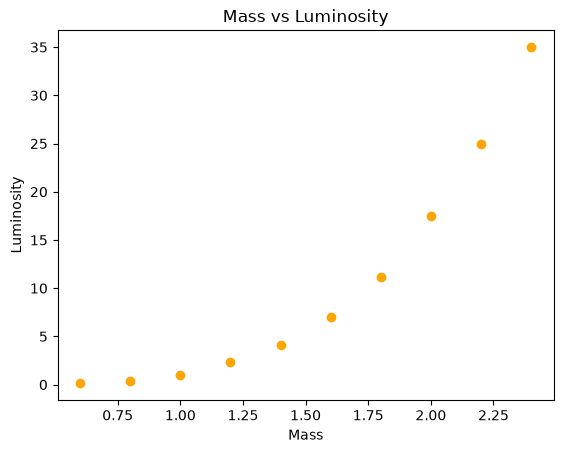

In [27]:
# First we create a new empty figure
plt.figure()

# Now we plot the data points
plt.scatter(mass, luminosity, color="orange")

# Then, we add labels and a title
plt.xlabel("Mass")
plt.ylabel("Luminosity")
plt.title("Mass vs Luminosity")

# Finally, we show the plot
plt.show()

### Describing the observed relation

The relationship between stellar mass and luminosity appears to be nonlinear. It's clear to see that as the stellar mass increases, the luminosity increases at a much faster rate, suggesting an upward-curving trend rather than a straight line.

A straight line does not appear to be adequate because it cannot fully capture the curved pattern. It would likely overestimate the luminosity of some stars and underestimate it for others, especially near the beginning and the end of the observed range. These systematic errors suggest that a nonlinear model may provide a better fit.

___

## 3. Implementing the learning algorithm

We'll use the model:

$$
f_{w,b}(x^{(i)}) = w x^{(i)} + b
$$

where:
 - $w$ is the slope,
 - $b$ the intercept.

In [28]:
def predict(w,x,b):
    return w * x + b

w_test = 0.0
b_test = 0.0
y_hat_test = predict(w_test, mass, b_test)

We define the **mean squared error** as the cost function, just as it was made in class:

$$
J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big)^2
$$



In [29]:
def compute_cost(w, b, x, y):
    m = x.shape[0]
    cost = np.sum(predict(w,x,b) - y)**2 / (2*m) # Is possible to use predict()?
    return cost

We use **gradient descent** with the update rules:

$$
\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big) x^{(i)}, \quad
\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big)
$$

Update:

$$
w := w - \alpha \frac{\partial J}{\partial w}, \quad
b := b - \alpha \frac{\partial J}{\partial b}
$$

In [30]:
def compute_gradients(x,y,w,b):
    m = x.shape[0]

    # Derivative of the cost function with respect to w
    df_dw = np.sum(predict(w,x,b)- y)*x / m

    # Derivative of the cost function with respect to b
    df_db = np.sum(predict(w,x,b) - y) / m

    return df_dw, df_db

Now, let's implement the gradient descent loop:

In [ ]:
def gradient_descent(x, y, w_init, b_init, alpha, num_iterations):
    w = w_init
    b = b_init
    history = []

    for i in range(num_iterations):
        # Compute gradients
        df_dw, df_db = compute_gradients(x, y, w, b)

        # Update parameters
        w = w - alpha * df_dw
        b = b - alpha * df_db

        # Save the cost
        cost = compute_cost(w, b, x, y)
        history.append(cost)

        # We are going to print the cost every 100 iterations
        if i % max(1, num_iterations // 10) == 0:
            print(f"Iteration {i:4d}: w = {w:7.4f}, b = {b:7.4f}, cost = {cost:8.4f}")


    return w, b, history

We can see that this functions support design matrices thanks with one or more features thanks to NumPy library